# Analyse des résultats du traitement des textes

Ce notebook analyse les résultats du processage des textes contenus dans `batch_graphdata_chunked_results.pkl`

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import numpy as np

plt.style.use('default')
sns.set_palette("husl")

## Chargement des données

In [2]:
# Chargement du fichier pickle
with open('batch_graphdata_chunked_results.pkl', 'rb') as f:
    data = pickle.load(f)

print(f"Nombre de fichiers traités: {len(data)}")
print(f"Type des données: {type(data)}")

Nombre de fichiers traités: 7
Type des données: <class 'list'>


## Vue d'ensemble des données

In [3]:
# Aperçu de la structure des données
if data:
    sample = data[0]
    print("Structure d'un échantillon:")
    for key in sample.keys():
        print(f"- {key}: {type(sample[key])}")
        if isinstance(sample[key], list) and sample[key]:
            print(f"  Premier élément: {type(sample[key][0])}")

Structure d'un échantillon:
- entities: <class 'list'>
- events: <class 'list'>
- relations: <class 'list'>
- file_name: <class 'str'>
- file_path: <class 'str'>
- hash: <class 'str'>
- processed_at: <class 'str'>
- text_length: <class 'int'>
- processing_method: <class 'str'>


## Analyse des entités

In [4]:
# Extraction et analyse des entités
all_entities = []
entity_types = []
entity_intentions = []

for file_data in data:
    if 'entities' in file_data:
        for entity in file_data['entities']:
            all_entities.append(entity)
            if 'type' in entity:
                entity_types.append(entity['type'])
            if 'intentions' in entity:
                entity_intentions.extend(entity['intentions'])

print(f"Nombre total d'entités: {len(all_entities)}")
print(f"Types d'entités uniques: {len(set(entity_types))}")
print(f"Intentions totales: {len(entity_intentions)}")

Nombre total d'entités: 77
Types d'entités uniques: 5
Intentions totales: 162


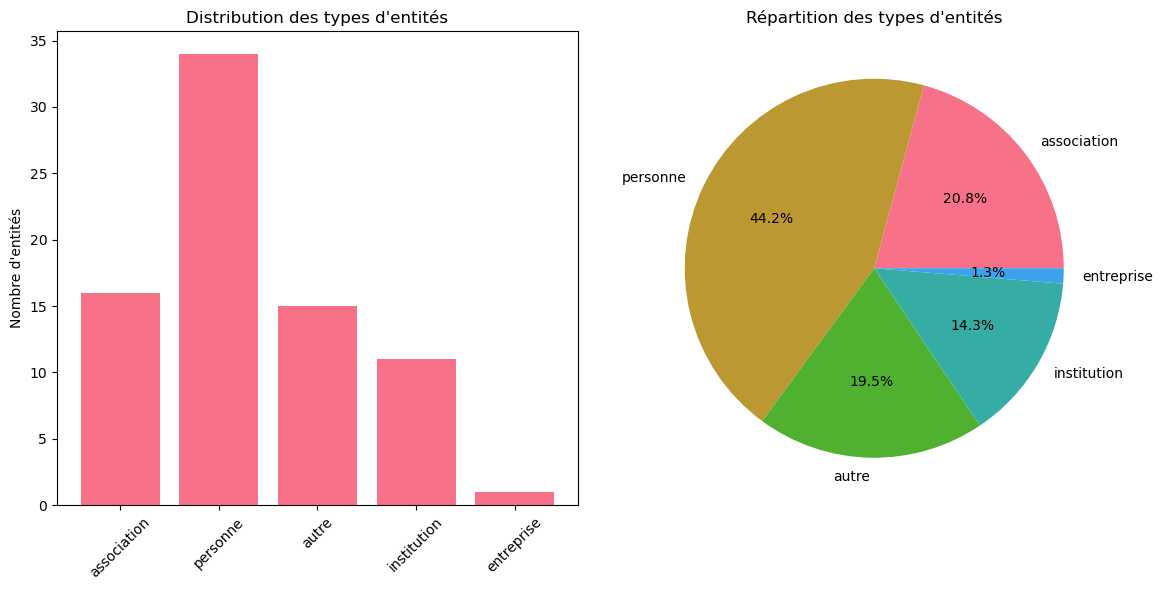

Détail des types d'entités:
- personne: 34
- association: 16
- autre: 15
- institution: 11
- entreprise: 1


In [5]:
# Distribution des types d'entités
type_counts = Counter(entity_types)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(type_counts.keys(), type_counts.values())
plt.title('Distribution des types d\'entités')
plt.xticks(rotation=45)
plt.ylabel('Nombre d\'entités')

plt.subplot(1, 2, 2)
plt.pie(type_counts.values(), labels=type_counts.keys(), autopct='%1.1f%%')
plt.title('Répartition des types d\'entités')

plt.tight_layout()
plt.show()

print("Détail des types d'entités:")
for entity_type, count in type_counts.most_common():
    print(f"- {entity_type}: {count}")

## Analyse des événements

In [6]:
# Extraction et analyse des événements
all_events = []
concert_styles = []
event_locations = []

for file_data in data:
    if 'events' in file_data:
        for event in file_data['events']:
            all_events.append(event)
            if 'concert_style' in event and event['concert_style']:
                concert_styles.append(event['concert_style'])
            if 'location' in event and event['location']:
                event_locations.append(event['location'])

print(f"Nombre total d'événements: {len(all_events)}")
print(f"Styles de concert uniques: {len(set(concert_styles))}")
print(f"Lieux d'événements uniques: {len(set(event_locations))}")

Nombre total d'événements: 30
Styles de concert uniques: 5
Lieux d'événements uniques: 14


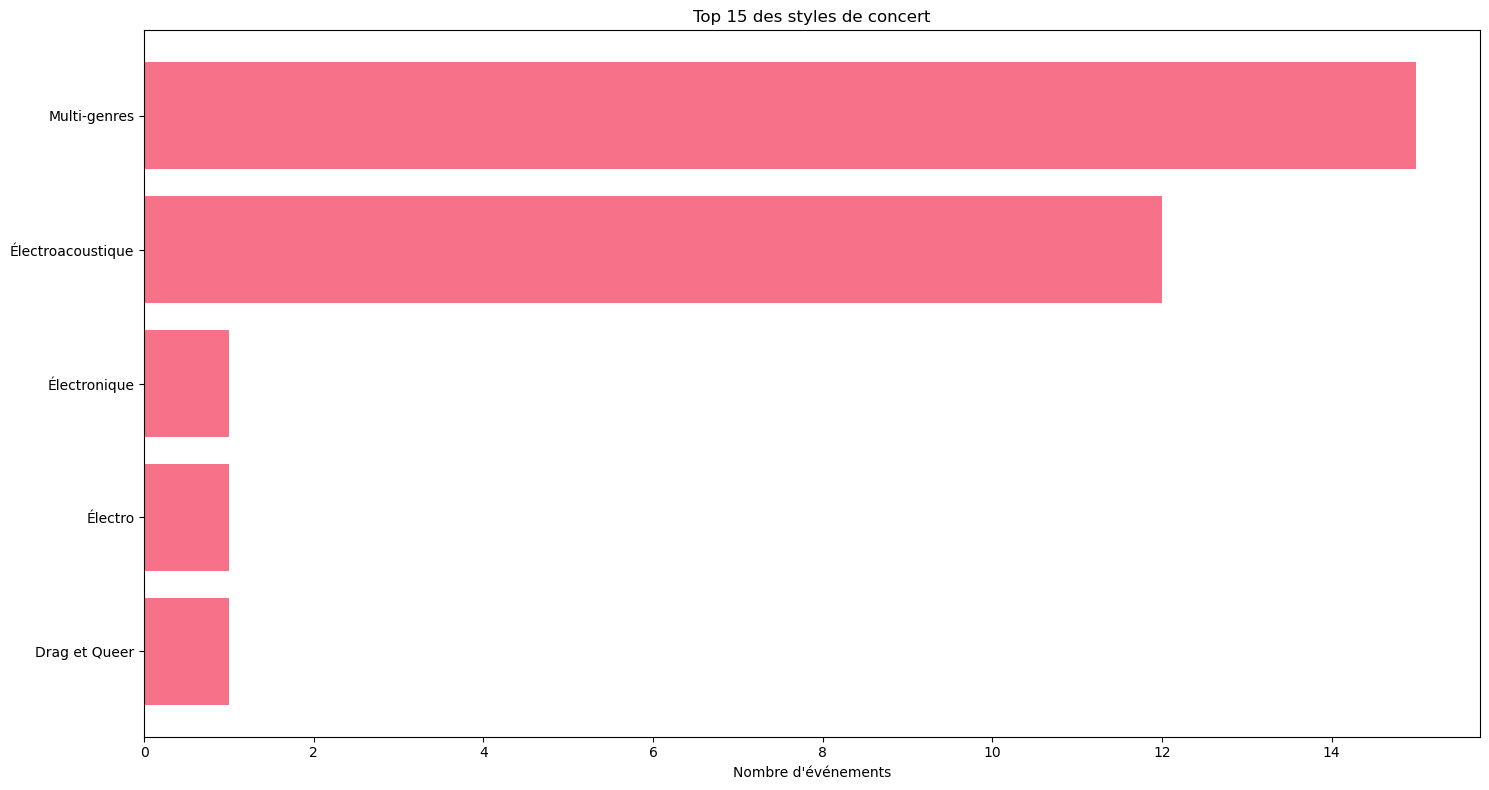

Top 10 des styles de concert:
- Multi-genres: 15
- Électroacoustique: 12
- Électronique: 1
- Électro: 1
- Drag et Queer: 1


In [7]:
# Analyse des styles de concert
style_counts = Counter(concert_styles)

plt.figure(figsize=(15, 8))
top_styles = style_counts.most_common(15)
styles, counts = zip(*top_styles)

plt.barh(range(len(styles)), counts)
plt.yticks(range(len(styles)), styles)
plt.title('Top 15 des styles de concert')
plt.xlabel('Nombre d\'événements')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 des styles de concert:")
for style, count in style_counts.most_common(10):
    print(f"- {style}: {count}")

## Analyse des relations

Nombre total de relations: 71


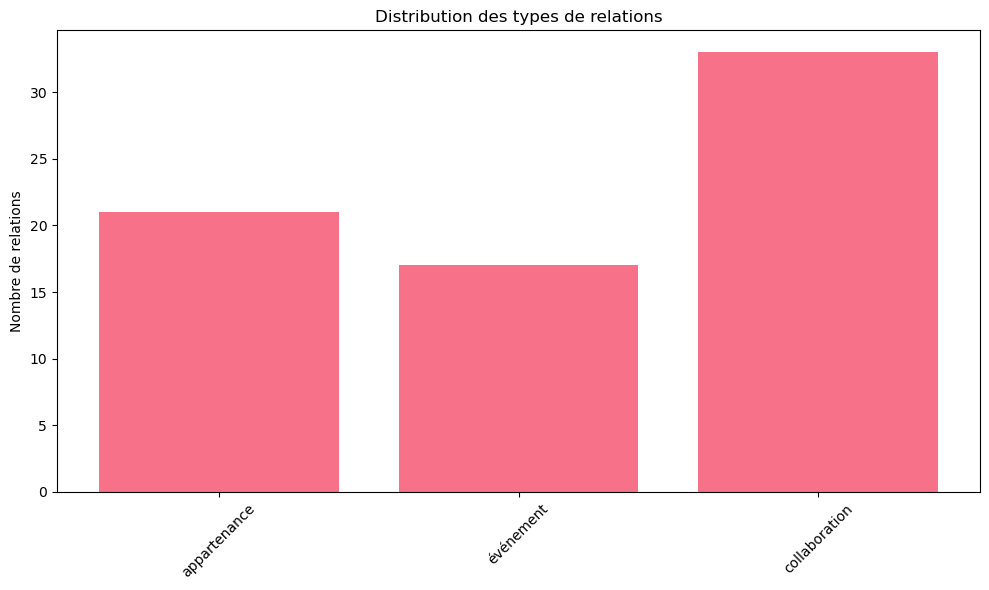

Types de relations:
- collaboration: 33
- appartenance: 21
- événement: 17


In [8]:
# Extraction et analyse des relations
all_relations = []
relation_types = []

for file_data in data:
    if 'relations' in file_data:
        for relation in file_data['relations']:
            all_relations.append(relation)
            if 'relation_type' in relation:
                relation_types.append(relation['relation_type'])

print(f"Nombre total de relations: {len(all_relations)}")

# Distribution des types de relations&
relation_type_counts = Counter(relation_types)

plt.figure(figsize=(10, 6))
plt.bar(relation_type_counts.keys(), relation_type_counts.values())
plt.title('Distribution des types de relations')
plt.xticks(rotation=45)
plt.ylabel('Nombre de relations')
plt.tight_layout()
plt.show()

print("Types de relations:")
for rel_type, count in relation_type_counts.most_common():
    print(f"- {rel_type}: {count}")

## Analyse par fichier source

In [9]:
# Création d'un DataFrame pour l'analyse par fichier
file_stats = []

for file_data in data:
    stats = {
        'file_name': file_data.get('file_name', 'Unknown'),
        'nb_entities': len(file_data.get('entities', [])),
        'nb_events': len(file_data.get('events', [])),
        'nb_relations': len(file_data.get('relations', [])),
        'text_length': file_data.get('text_length', 0),
        'processing_method': file_data.get('processing_method', 'unknown'),
        'chunks_processed': file_data.get('chunks_processed', 1)
    }
    file_stats.append(stats)

df_files = pd.DataFrame(file_stats)
print(f"Statistiques sur {len(df_files)} fichiers:")
print(df_files.describe())

Statistiques sur 7 fichiers:
       nb_entities  nb_events  nb_relations   text_length  chunks_processed
count     7.000000   7.000000      7.000000      7.000000               7.0
mean     11.000000   4.285714     10.142857   8602.714286               1.0
std      10.424331   5.648430     10.683766   9429.539061               0.0
min       0.000000   0.000000      0.000000      0.000000               1.0
25%       4.500000   1.000000      3.500000   2378.000000               1.0
50%      11.000000   1.000000      5.000000   5614.000000               1.0
75%      12.500000   7.000000     14.000000  11639.500000               1.0
max      32.000000  13.000000     31.000000  26570.000000               1.0


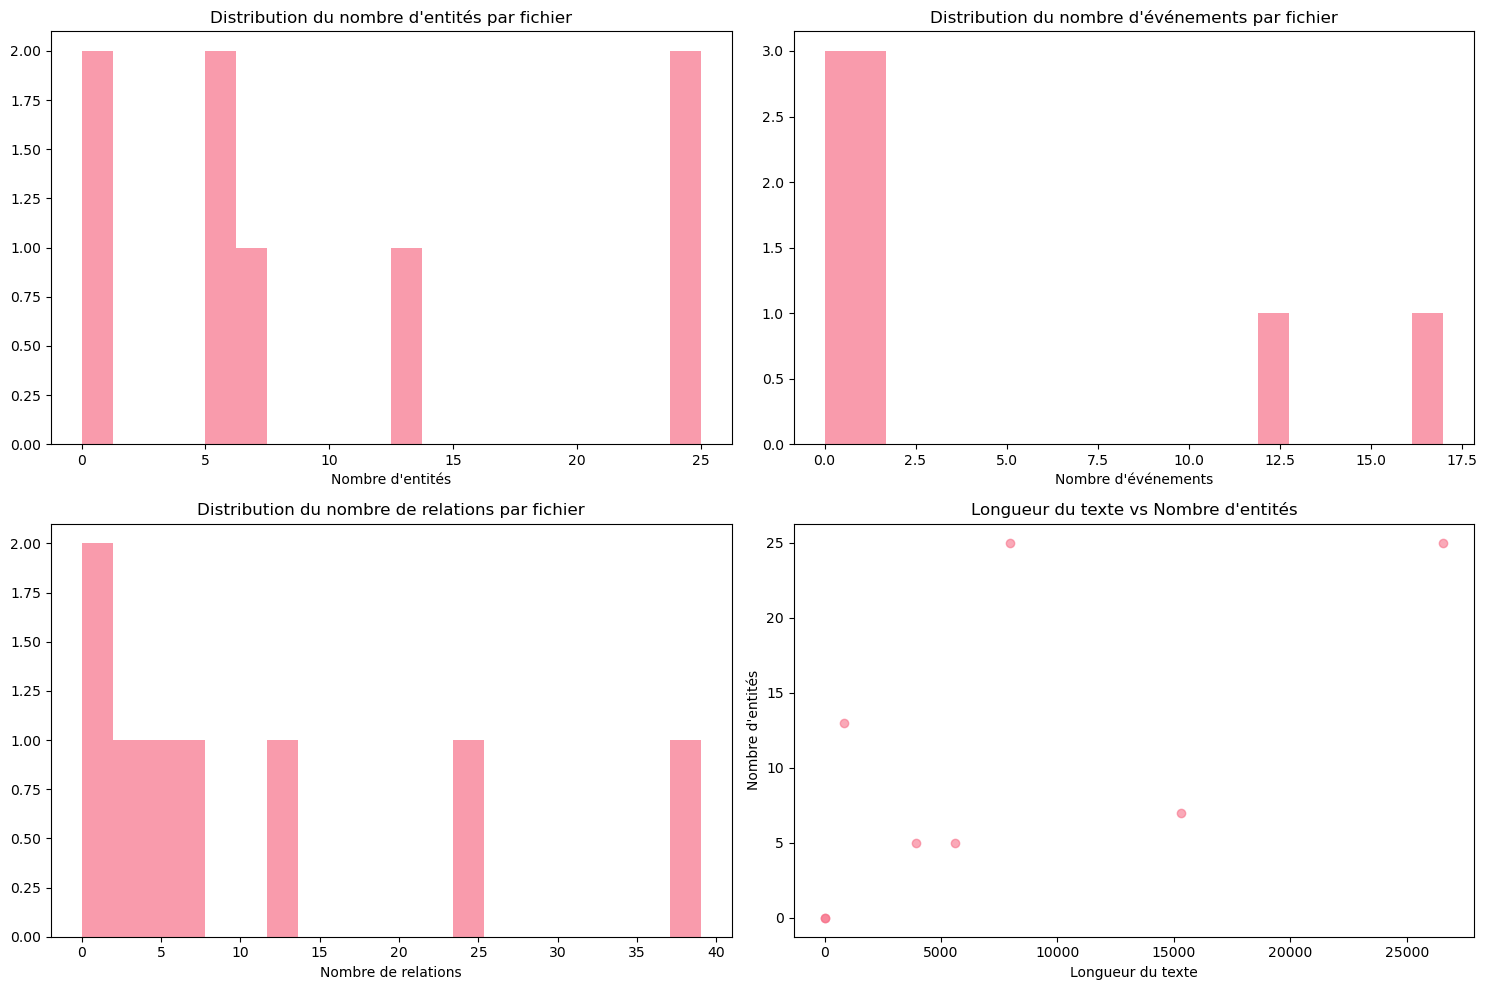

In [10]:
# Visualisation des statistiques par fichier
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution du nombre d'entités par fichier
axes[0, 0].hist(df_files['nb_entities'], bins=20, alpha=0.7)
axes[0, 0].set_title('Distribution du nombre d\'entités par fichier')
axes[0, 0].set_xlabel('Nombre d\'entités')

# Distribution du nombre d'événements par fichier
axes[0, 1].hist(df_files['nb_events'], bins=20, alpha=0.7)
axes[0, 1].set_title('Distribution du nombre d\'événements par fichier')
axes[0, 1].set_xlabel('Nombre d\'événements')

# Distribution du nombre de relations par fichier
axes[1, 0].hist(df_files['nb_relations'], bins=20, alpha=0.7)
axes[1, 0].set_title('Distribution du nombre de relations par fichier')
axes[1, 0].set_xlabel('Nombre de relations')

# Relation entre longueur du texte et nombre d'entités
axes[1, 1].scatter(df_files['text_length'], df_files['nb_entities'], alpha=0.6)
axes[1, 1].set_title('Longueur du texte vs Nombre d\'entités')
axes[1, 1].set_xlabel('Longueur du texte')
axes[1, 1].set_ylabel('Nombre d\'entités')

plt.tight_layout()
plt.show()

## Analyse des intentions

Nombre total d'intentions: 162
Intentions uniques: 91


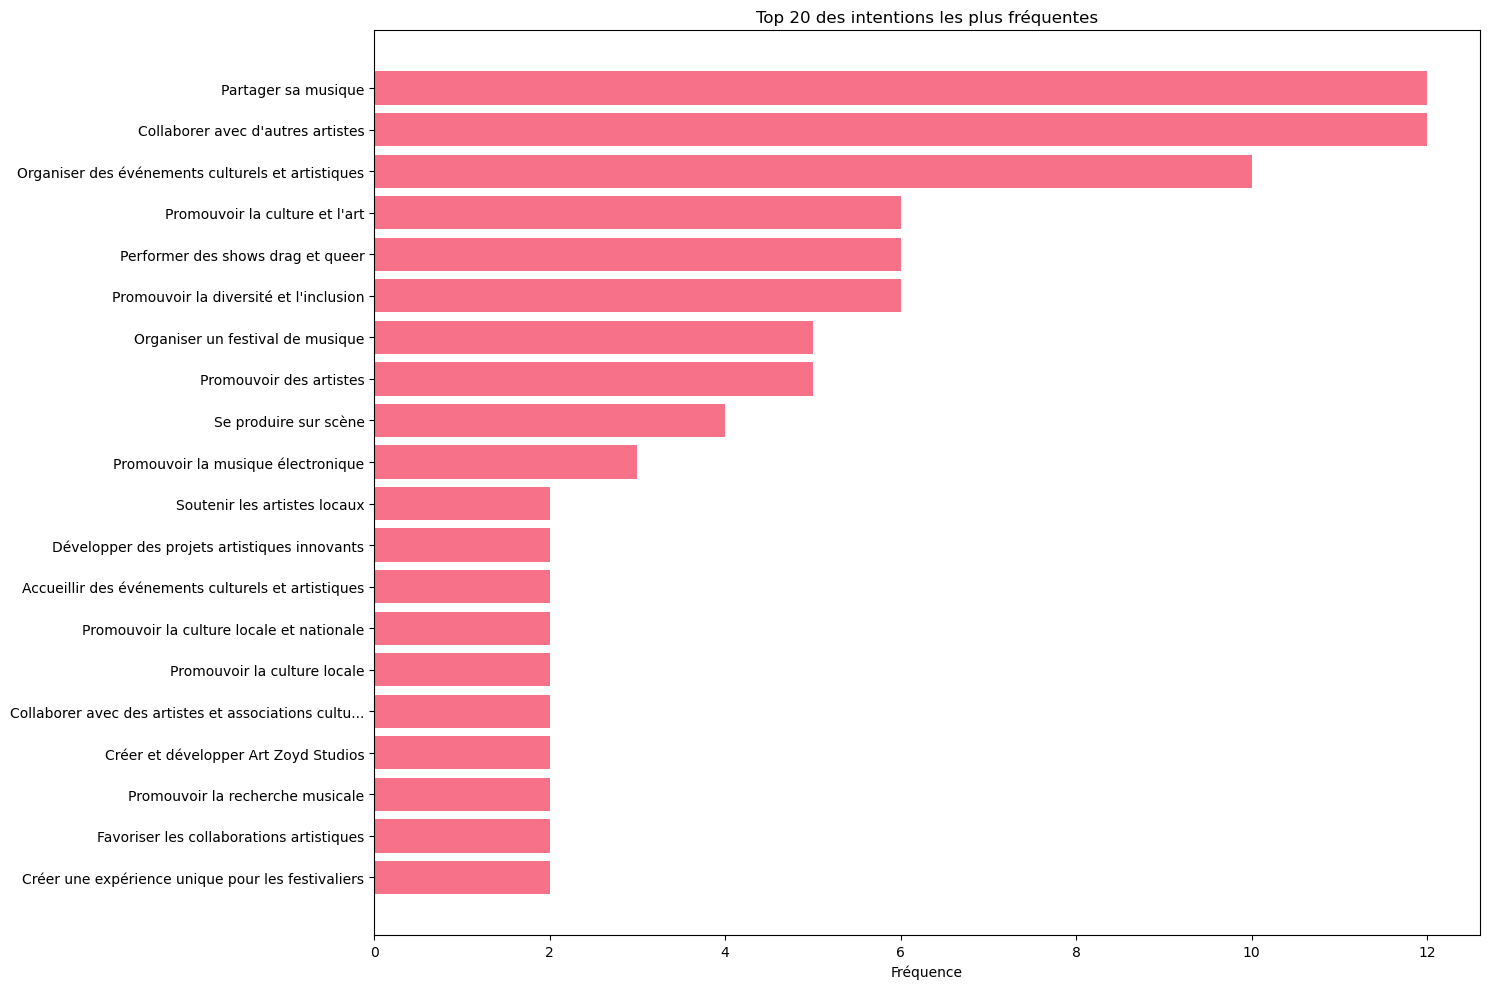


Top 10 des intentions:
- Partager sa musique: 12
- Collaborer avec d'autres artistes: 12
- Organiser des événements culturels et artistiques: 10
- Promouvoir la culture et l'art: 6
- Performer des shows drag et queer: 6
- Promouvoir la diversité et l'inclusion: 6
- Organiser un festival de musique: 5
- Promouvoir des artistes: 5
- Se produire sur scène: 4
- Promouvoir la musique électronique: 3


In [10]:
# Analyse des intentions les plus fréquentes
intention_counts = Counter(entity_intentions)

print(f"Nombre total d'intentions: {len(entity_intentions)}")
print(f"Intentions uniques: {len(intention_counts)}")

# Top 20 des intentions
plt.figure(figsize=(15, 10))
top_intentions = intention_counts.most_common(20)
intentions, counts = zip(*top_intentions)

plt.barh(range(len(intentions)), counts)
plt.yticks(range(len(intentions)), [intent[:50] + '...' if len(intent) > 50 else intent for intent in intentions])
plt.title('Top 20 des intentions les plus fréquentes')
plt.xlabel('Fréquence')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 des intentions:")
for intention, count in intention_counts.most_common(10):
    print(f"- {intention}: {count}")

## Analyse des méthodes de traitement

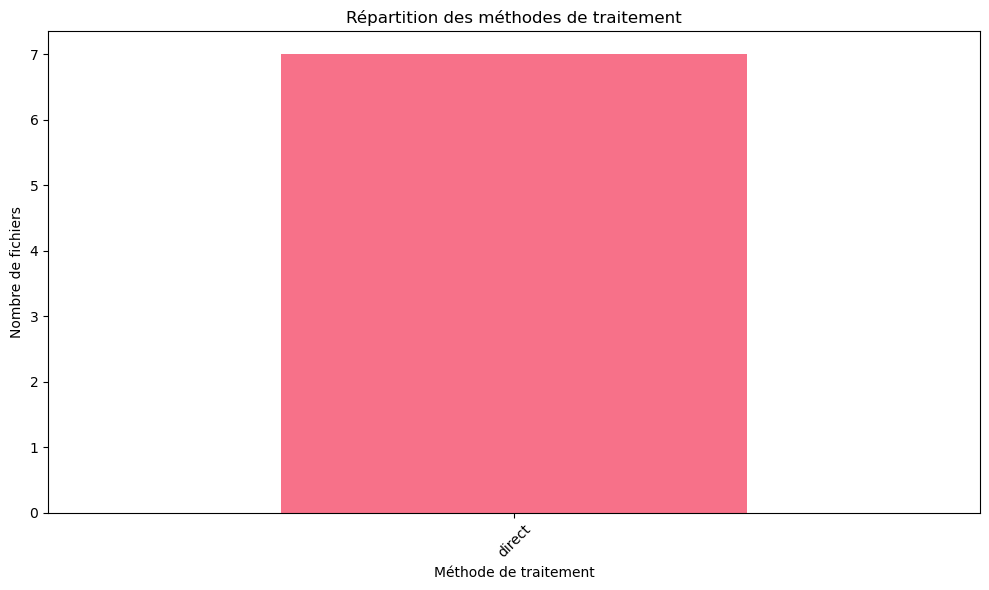

Méthodes de traitement:
- direct: 7 fichiers


In [11]:
# Analyse des méthodes de traitement
processing_methods = df_files['processing_method'].value_counts()

plt.figure(figsize=(10, 6))
processing_methods.plot(kind='bar')
plt.title('Répartition des méthodes de traitement')
plt.xlabel('Méthode de traitement')
plt.ylabel('Nombre de fichiers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Méthodes de traitement:")
for method, count in processing_methods.items():
    print(f"- {method}: {count} fichiers")

## Fichiers les plus riches en données

Top 10 des fichiers les plus riches en données:
           file_name  nb_entities  nb_events  nb_relations  richness_score
         Art_Point_M           32         13            31            88.7
    Art_Zoyd_studios            4         12            15            40.0
        Amikal_sonic           13          1            13            30.1
 A_Gauche_de_la_Lune           11          1             5            18.5
               Fungi           12          1             3            17.1
cleaning_report.json            5          2             4            12.8
Ah_Bon___productions            0          0             0             0.0


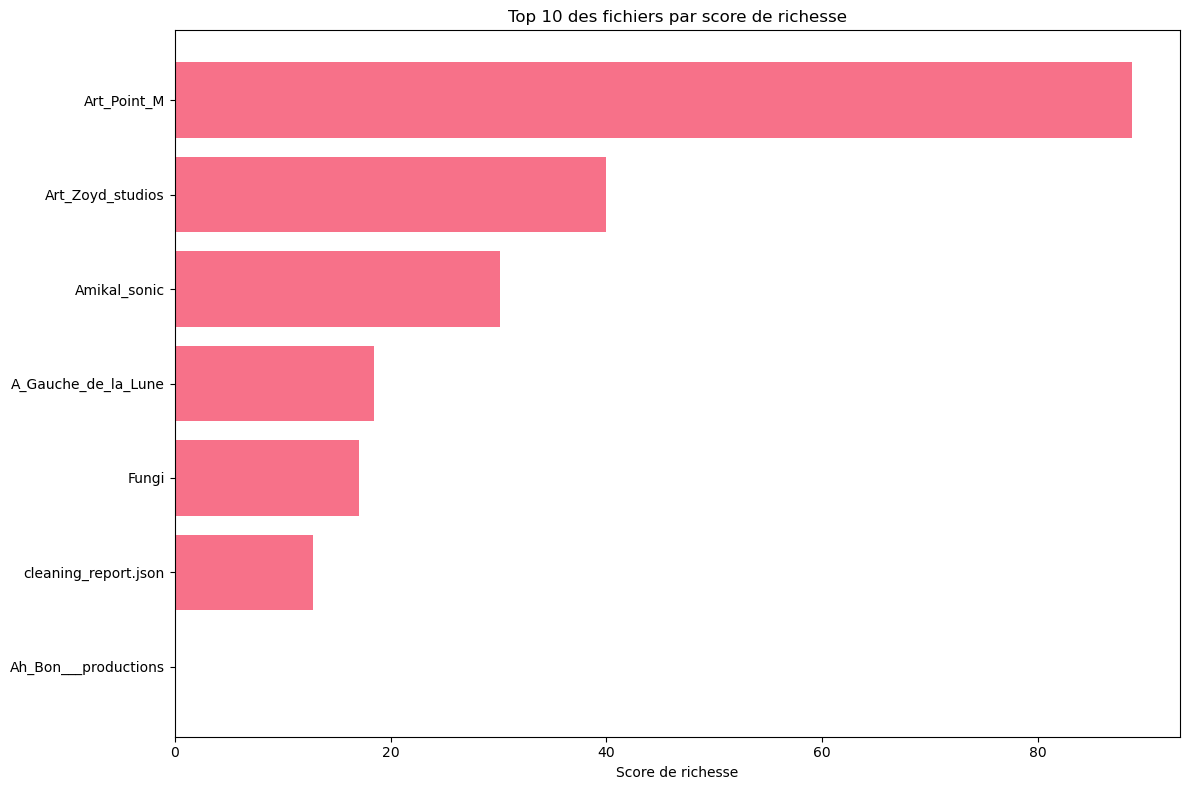

In [12]:
# Calcul d'un score de richesse pour chaque fichier
df_files['richness_score'] = (
    df_files['nb_entities'] * 1.0 + 
    df_files['nb_events'] * 1.5 + 
    df_files['nb_relations'] * 1.2
)

# Top 10 des fichiers les plus riches
top_files = df_files.nlargest(10, 'richness_score')

print("Top 10 des fichiers les plus riches en données:")
print(top_files[['file_name', 'nb_entities', 'nb_events', 'nb_relations', 'richness_score']].to_string(index=False))

# Visualisation
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_files)), top_files['richness_score'])
plt.yticks(range(len(top_files)), top_files['file_name'])
plt.title('Top 10 des fichiers par score de richesse')
plt.xlabel('Score de richesse')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Fichiers avec peu ou pas de données